# SECTION 1: Data exploration and pre-processing

In [ ]:
#install required packages --- IGNORE ---
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
#import libraries --- IGNORE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load of the database of ssh attacks.

In [3]:
# -----------------------
# LOAD THE DATA
# -----------------------
df = pd.read_parquet("ssh_attacks.parquet")
print(df.head())

   session_id                                       full_session  \
0           0  enable ; system ; shell ; sh ; cat /proc/mount...   
1           1  enable ; system ; shell ; sh ; cat /proc/mount...   
2           2  enable ; system ; shell ; sh ; cat /proc/mount...   
3           3  enable ; system ; shell ; sh ; cat /proc/mount...   
4           4  enable ; system ; shell ; sh ; cat /proc/mount...   

                    first_timestamp               Set_Fingerprint  
0  2019-06-04 09:45:11.151186+00:00  [Defense Evasion, Discovery]  
1  2019-06-04 09:45:50.396610+00:00  [Defense Evasion, Discovery]  
2  2019-06-04 09:54:41.863315+00:00  [Defense Evasion, Discovery]  
3  2019-06-04 10:22:14.623875+00:00  [Defense Evasion, Discovery]  
4  2019-06-04 10:37:19.725874+00:00  [Defense Evasion, Discovery]  


### 1. Analisys of temporal series.


--- 1. Temporal Analysis of Attacks ---


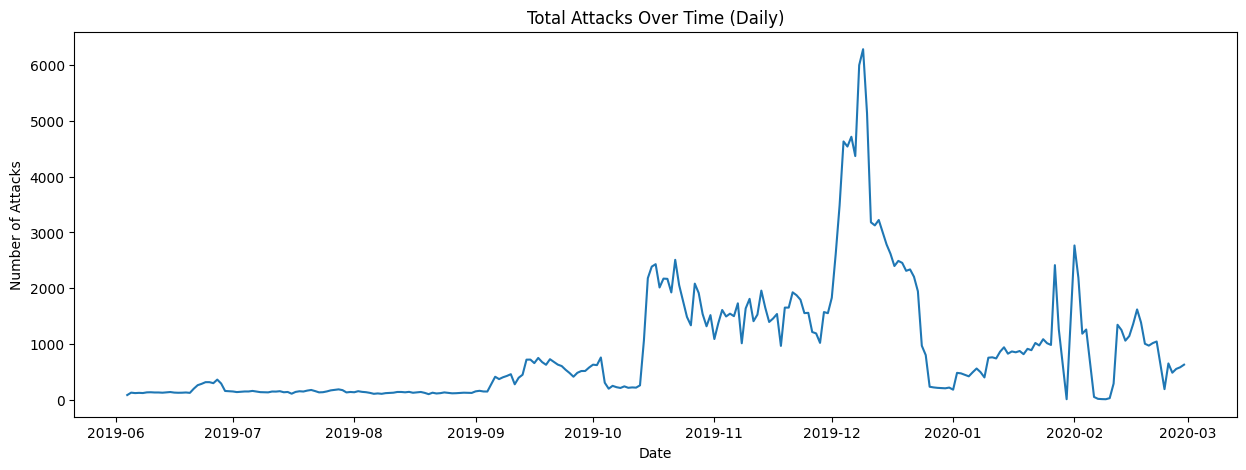

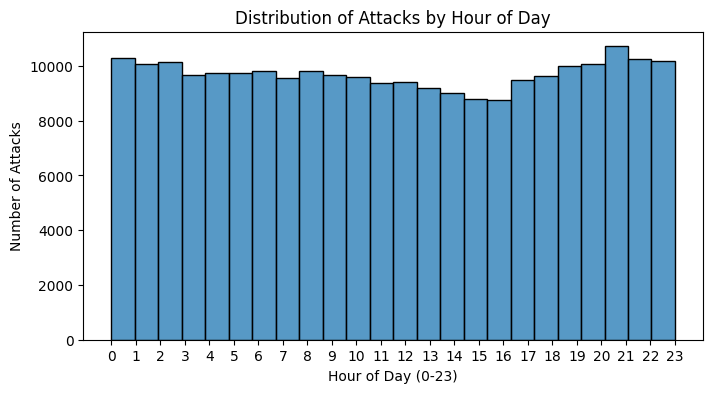

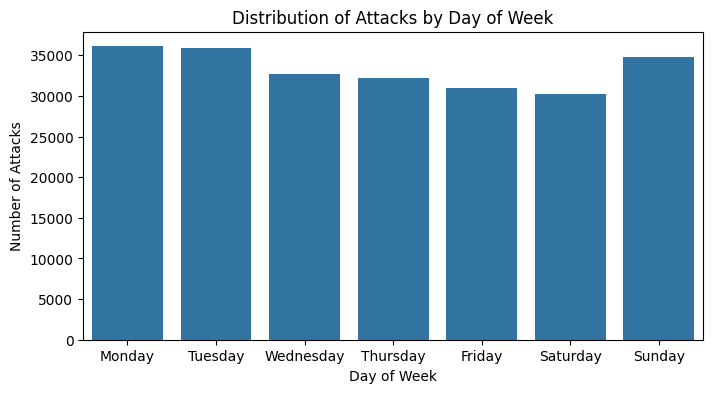

In [7]:
## Question 1: Temporal Analysis
print("\n--- 1. Temporal Analysis of Attacks ---")

if not df.empty and 'first_timestamp' in df.columns:
    # Ensure the column is of datetime type
    df['first_timestamp'] = pd.to_datetime(df['first_timestamp'])

    # Extract temporal components
    df['date'] = df['first_timestamp'].dt.date
    df['hour'] = df['first_timestamp'].dt.hour
    df['day_of_week'] = df['first_timestamp'].dt.dayofweek  # Monday=0, Sunday=6

    # 1. Time series plot (Attacks per day)
    attacks_per_day = df.groupby('date').size()
    plt.figure(figsize=(15, 5))
    attacks_per_day.plot()
    plt.title('Total Attacks Over Time (Daily)')
    plt.xlabel('Date')
    plt.ylabel('Number of Attacks')
    plt.show()

    # 2. Distribution plot by hour of the day
    plt.figure(figsize=(8, 4))
    sns.histplot(df['hour'], bins=24, kde=False)
    plt.title('Distribution of Attacks by Hour of Day')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Number of Attacks')
    plt.xticks(range(0, 24))
    plt.show()

    # 3. Distribution plot by day of the week
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    attacks_per_weekday = df.groupby('day_of_week').size().reindex(range(7), fill_value=0)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=attacks_per_weekday.index, y=attacks_per_weekday.values)
    plt.title('Distribution of Attacks by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Number of Attacks')
    plt.xticks(ticks=range(7), labels=days, rotation=0)
    plt.show()
else:
    print("Unable to perform temporal analysis.")


=== CHARACTER COUNTS ===
count    233035.000000
mean       1013.865119
std        2282.583441
min           3.000000
25%         614.000000
50%         620.000000
75%        1415.000000
max      203442.000000
Name: n_chars, dtype: float64

Unique character lengths: 790

=== WORD COUNTS ===
count    233035.000000
mean        120.801399
std          87.692157
min           2.000000
25%         116.000000
50%         116.000000
75%         138.000000
max       34404.000000
Name: n_words, dtype: float64

Unique word counts: 250


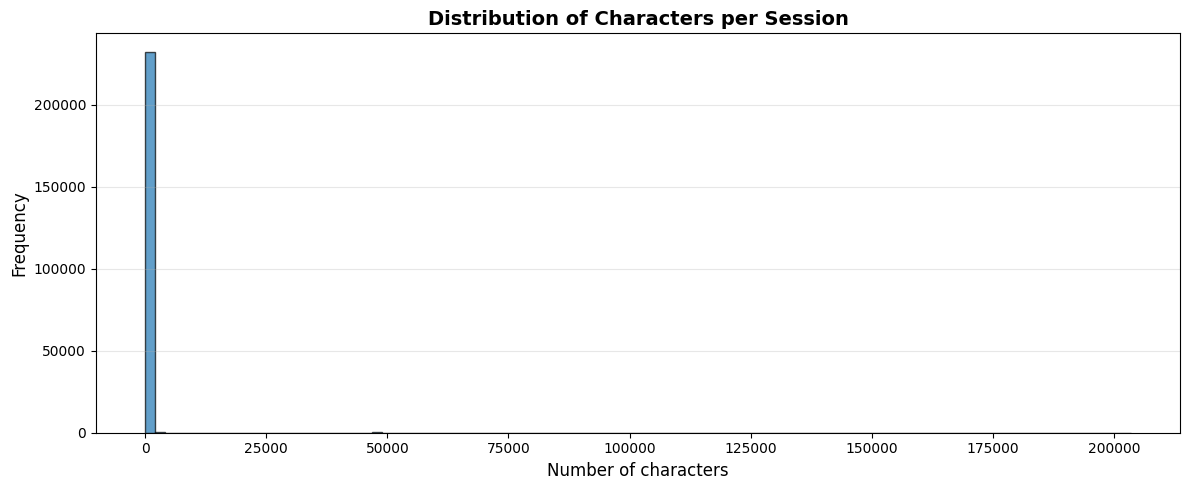

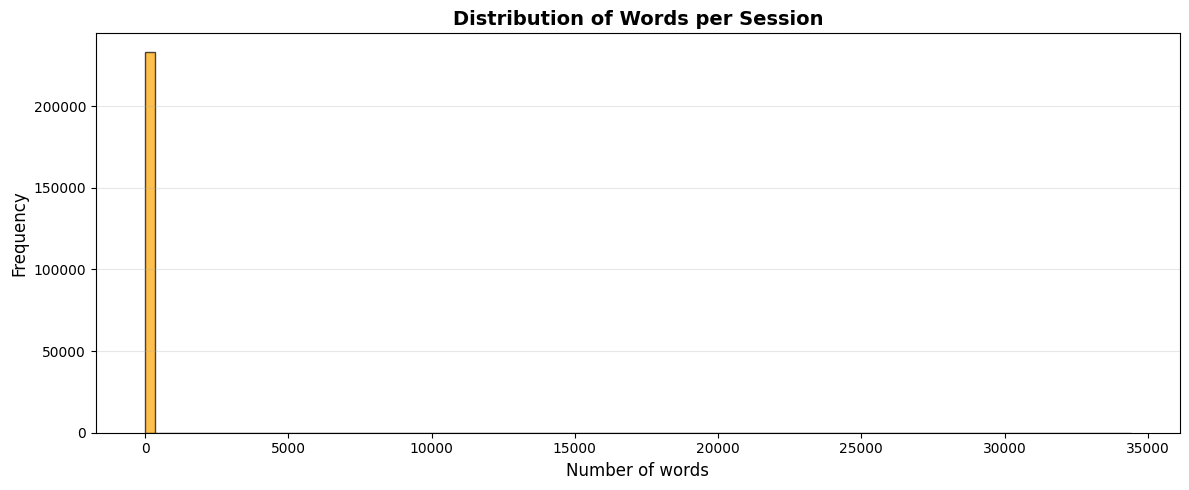

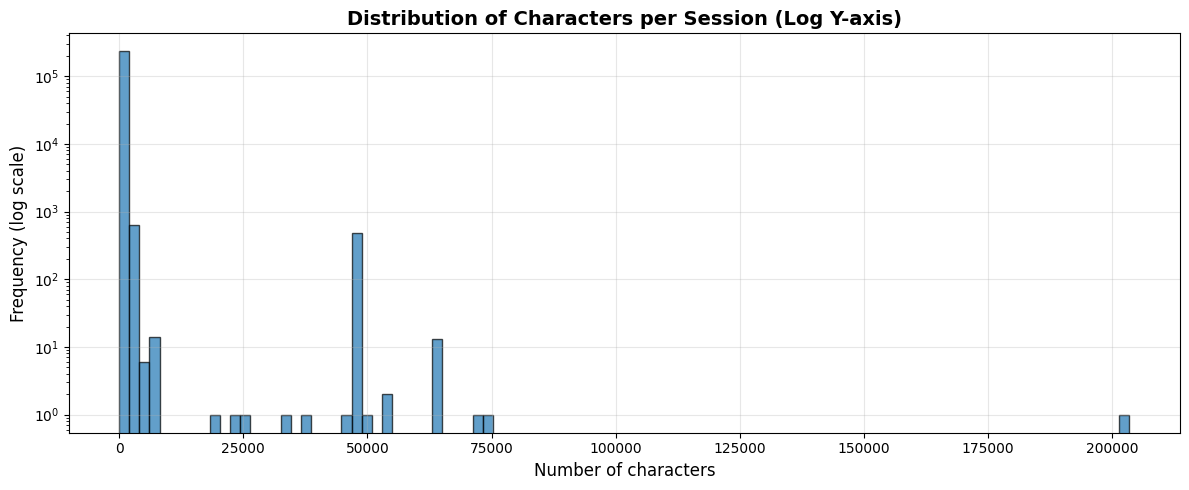

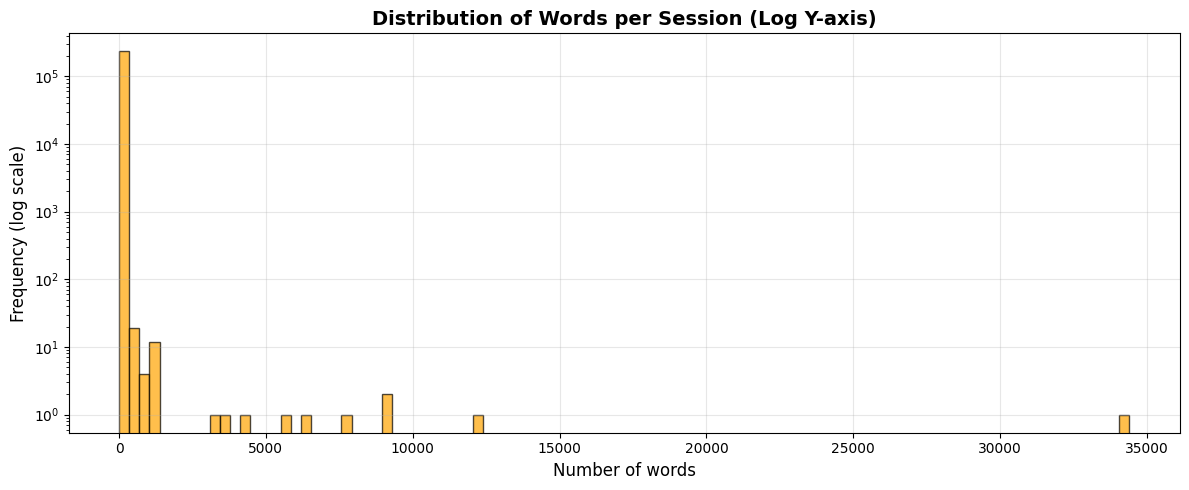

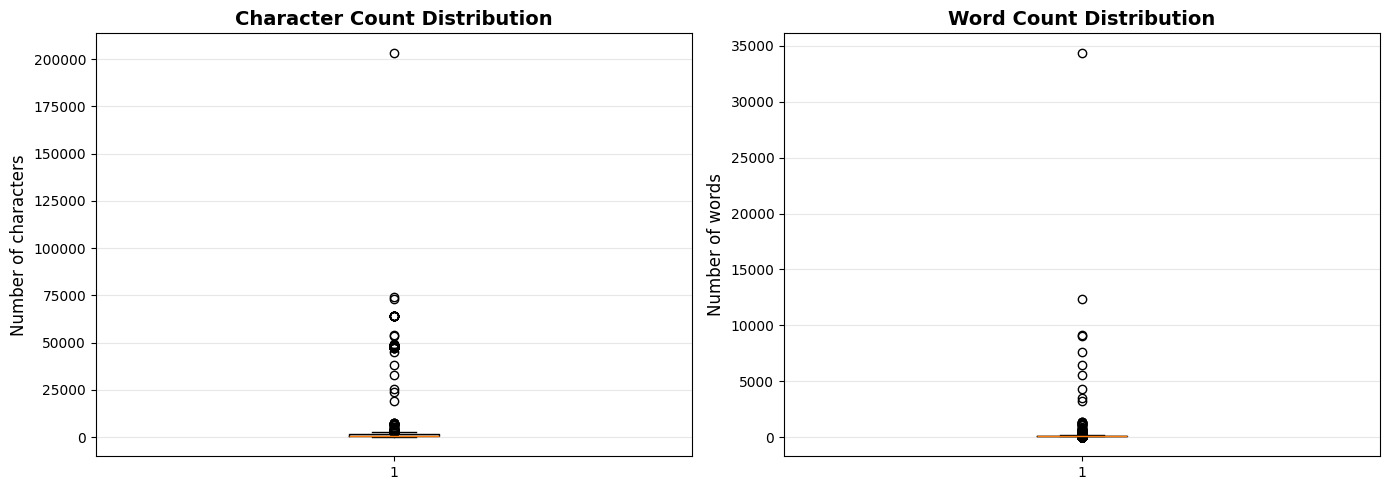

In [ ]:
# -----------------------
# FEATURE EXTRACTION
# -----------------------

# Convert to string and handle any NaN values
session_str = df['full_session'].astype(str)

# 1. Number of characters in each session (vectorized)
df['n_chars'] = session_str.apply(len)

# 2. Number of words in each session (vectorized)
df['n_words'] = session_str.str.split().apply(len)

# -----------------------
# SUMMARY STATISTICS
# -----------------------
print("=== CHARACTER COUNTS ===")
print(df['n_chars'].describe())
print("\nUnique character lengths:", df['n_chars'].nunique())

print("\n=== WORD COUNTS ===")
print(df['n_words'].describe())
print("\nUnique word counts:", df['n_words'].nunique())


# -----------------------
# HISTOGRAMS - LOG SCALE (Better for skewed data)
# -----------------------

# Character distribution - log scale on y-axis only
plt.figure(figsize=(12,5))
plt.hist(df['n_chars'], bins=100, edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.title("Distribution of Characters per Session (Log Y-axis)", fontsize=14, fontweight='bold')
plt.xlabel("Number of characters", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Word distribution - log scale on y-axis only
plt.figure(figsize=(12,5))
plt.hist(df['n_words'], bins=100, edgecolor='black', alpha=0.7, color='orange')
plt.yscale('log')
plt.title("Distribution of Words per Session (Log Y-axis)", fontsize=14, fontweight='bold')
plt.xlabel("Number of words", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------
# BOX PLOTS (Alternative view to see quartiles and outliers)
# -----------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character count boxplot
axes[0].boxplot(df['n_chars'], vert=True)
axes[0].set_ylabel('Number of characters', fontsize=12)
axes[0].set_title('Character Count Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Word count boxplot
axes[1].boxplot(df['n_words'], vert=True)
axes[1].set_ylabel('Number of words', fontsize=12)
axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Exercise 3

=== TOP 30 MOST COMMON WORDS (cleaned tokens) ===
Rank   Word                                          Count Percentage
----------------------------------------------------------------------
1      grep                                      1,278,484      6.78%
2      cat                                       1,082,651      5.75%
3      echo                                        957,748      5.08%
4      -l                                          640,285      3.40%
5      uname                                       639,136      3.39%
6      /proc/cpuinfo                               638,865      3.39%
7      name                                        638,772      3.39%
8      /var/tmp/.var03522123                       637,129      3.38%
9      rm                                          451,423      2.40%
10     -rf                                         429,957      2.28%
11     awk                                         426,372      2.26%
12     'print                          

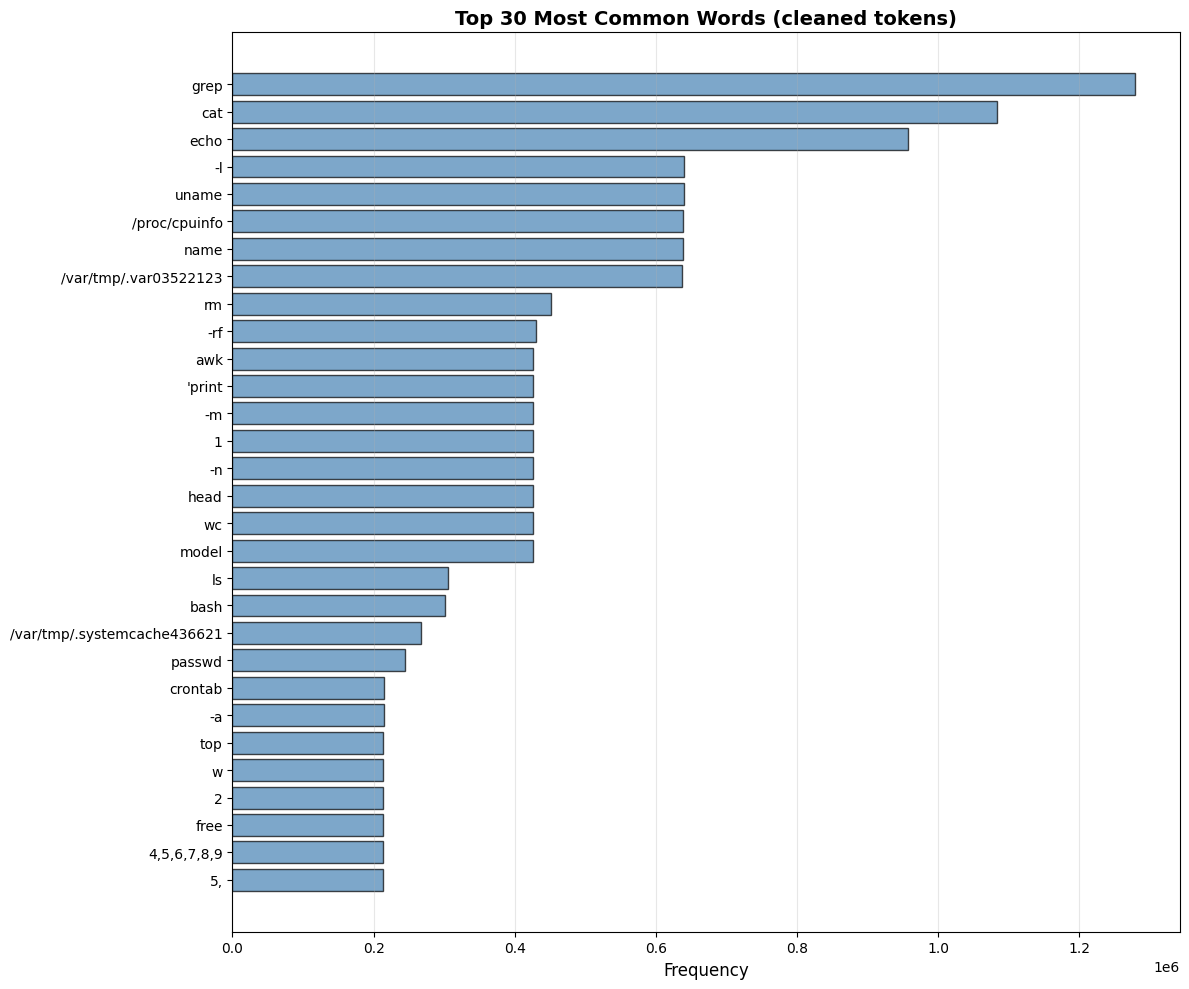

In [10]:
# -----------------------
# MOST COMMON WORDS ANALYSIS (using sklearn)
# -----------------------

from sklearn.feature_extraction.text import CountVectorizer
import re

# Preprocessing function: remove {, }, -, $ from tokens while keeping /
def clean_token(text):
    # Remove unwanted characters from each token
    text = text.replace('$', '').replace("'{}", '')
    text = text.replace('{', '').replace('}', '')
    return text

# Apply cleaning to all sessions
cleaned_sessions = df['full_session'].astype(str).apply(clean_token)

# Define custom stop words - remove punctuation and operators
custom_stop_words = [';', '||', '&&', '|', '>', '<', '(', ')', '[', ']', 
                     ',', '.', '!', '?', ':', '_', '=', '+', '*', '\\',
                     '`', '~', '@', '#', '%', '^', '&', '"', "'"]

# Create CountVectorizer
# - token_pattern=r'\S+' : splits on whitespace (keeps / in paths)
# - stop_words : removes punctuation and operators from counting
vectorizer = CountVectorizer(
    token_pattern=r'\S+',
    stop_words=custom_stop_words,
    max_features=None
)

# Fit and transform the cleaned sessions
X = vectorizer.fit_transform(cleaned_sessions)

# Get vocabulary and word counts
vocabulary = vectorizer.get_feature_names_out()
word_counts = X.sum(axis=0).A1  # Sum across all documents

# Create a sorted list of (word, count) tuples
word_count_pairs = list(zip(vocabulary, word_counts))
word_count_pairs.sort(key=lambda x: x[1], reverse=True)

# Get top 30
top_30_words = word_count_pairs[:30]

print("=== TOP 30 MOST COMMON WORDS (cleaned tokens) ===")
print(f"{'Rank':<6} {'Word':<40} {'Count':>10} {'Percentage':>10}")
print("-" * 70)
total_words = word_counts.sum()
for i, (word, count) in enumerate(top_30_words, 1):
    percentage = (count / total_words) * 100
    print(f"{i:<6} {word:<40} {int(count):>10,} {percentage:>9.2f}%")

print(f"\nTotal unique words (vocabulary size): {len(vocabulary):,}")
print(f"Total word occurrences: {int(total_words):,}")

# -----------------------
# VISUALIZATION OF TOP WORDS
# -----------------------

# Extract words and counts for plotting
words = [word for word, count in top_30_words]
counts = [count for word, count in top_30_words]

# Horizontal bar chart (better for long words/paths)
plt.figure(figsize=(12, 10))
plt.barh(range(len(words)), counts, color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(words)), words, fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 30 Most Common Words (cleaned tokens)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Most common at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Intent Analysis (Set_Fingerprint)

=== INTENT DISTRIBUTION ANALYSIS ===

--- Intents per Session ---
count    233035.000000
mean          2.394173
std           0.523645
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           7.000000
Name: n_intents, dtype: float64

Most common number of intents per session:
n_intents
2    136458
3     92571
1      2928
4      1025
5        50
6         2
7         1
Name: count, dtype: int64


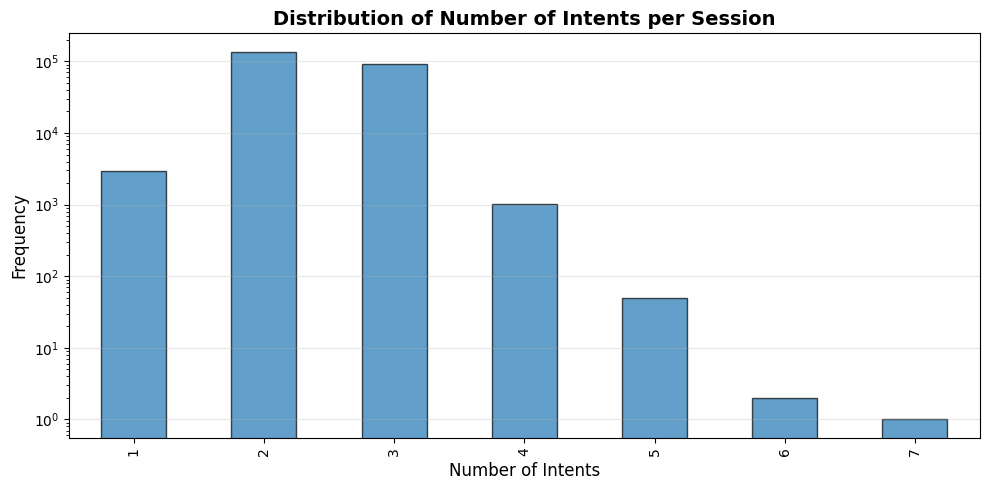


--- Top 10 Most Common Intents ---
Rank   Intent                                        Count Percentage
----------------------------------------------------------------------
1      Discovery                                   232,145     41.61%
2      Persistence                                 211,295     37.87%
3      Execution                                    92,927     16.66%
4      Defense Evasion                              18,999      3.41%
5      Harmless                                      2,206      0.40%
6      Other                                           327      0.06%
7      Impact                                           27      0.00%


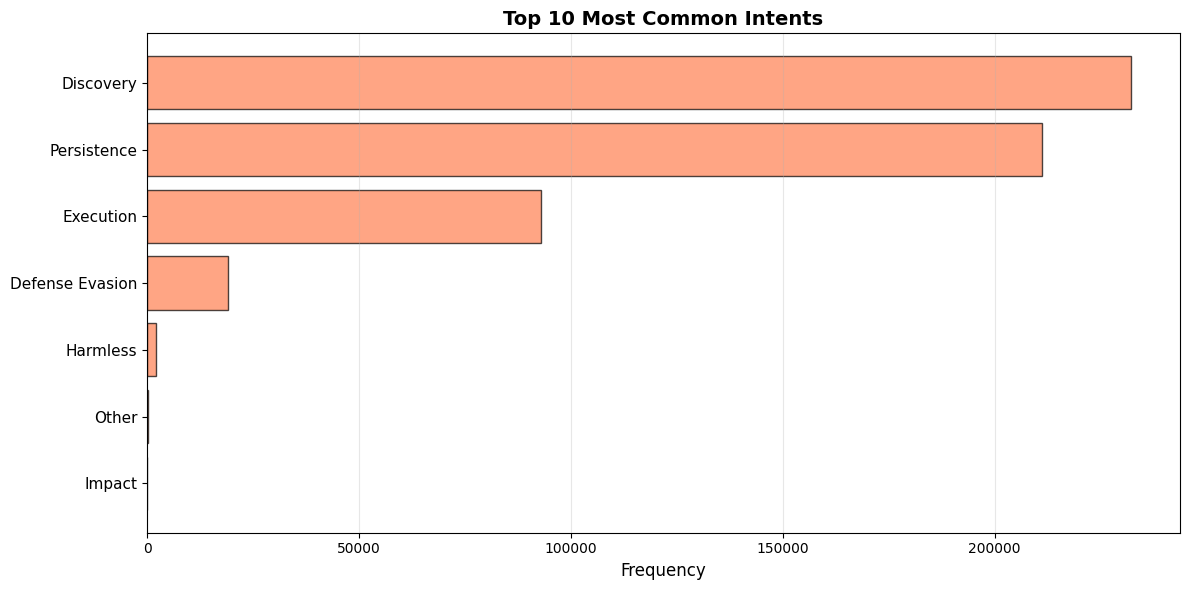


--- Top 10 Most Common Intent Combinations ---
Rank   Intent Combination                                                Count
--------------------------------------------------------------------------------
1      ['Discovery', 'Persistence']                                    117,951
2      ['Discovery', 'Execution', 'Persistence']                        90,510
3      ['Defense Evasion', 'Discovery']                                 17,909
4      ['Discovery']                                                     2,237
5      ['Discovery', 'Harmless', 'Persistence']                          1,693
6      ['Defense Evasion', 'Discovery', 'Execution', 'Persistence']        512
7      ['Execution']                                                       453
8      ['Discovery', 'Execution']                                          398
9      ['Discovery', 'Execution', 'Other', 'Persistence']                  301
10     ['Defense Evasion', 'Discovery', 'Execution']                       291

-

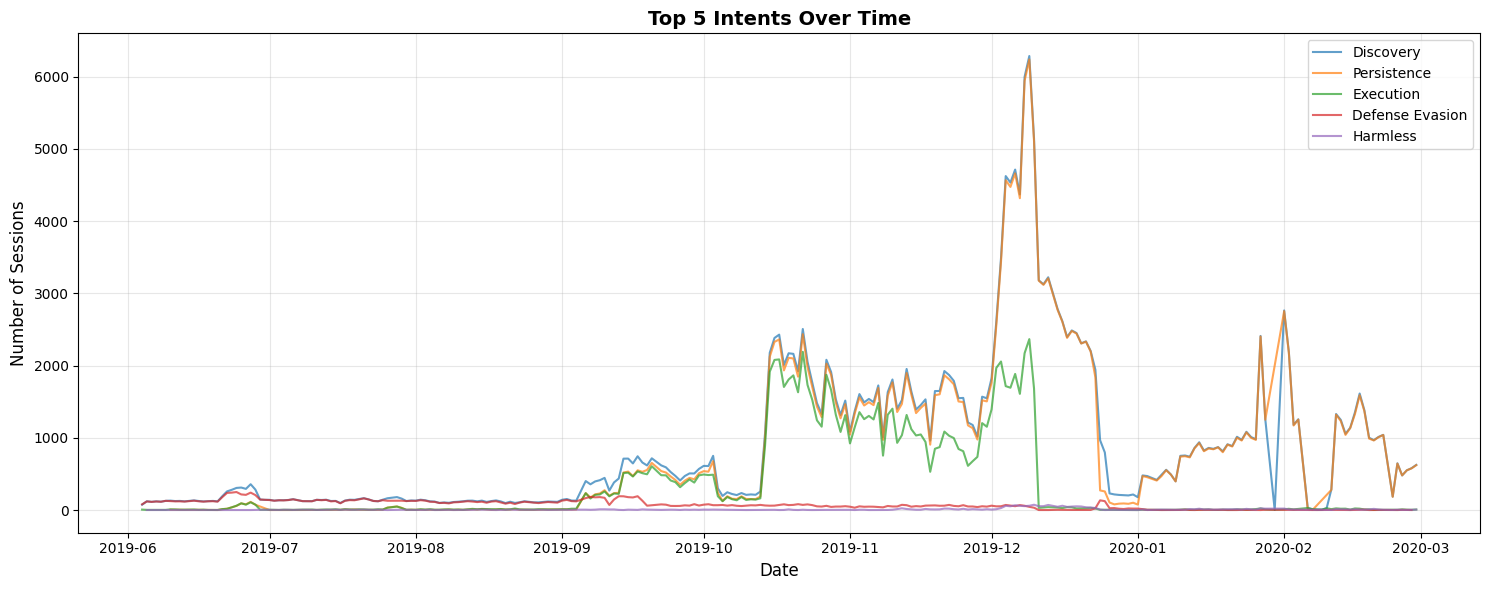


Intent analysis complete!


In [4]:
# -----------------------
# INTENT ANALYSIS
# -----------------------

import ast
from collections import Counter

print("=== INTENT DISTRIBUTION ANALYSIS ===\n")

# Parse Set_Fingerprint (stored as string representation of list)
df['fingerprint_list'] = df['Set_Fingerprint'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 1. Number of intents per session
df['n_intents'] = df['fingerprint_list'].apply(len)

print("--- Intents per Session ---")
print(df['n_intents'].describe())
print(f"\nMost common number of intents per session:")
print(df['n_intents'].value_counts().head(10))

# Visualization: Distribution of number of intents per session
plt.figure(figsize=(10, 5))
df['n_intents'].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Distribution of Number of Intents per Session', fontsize=14, fontweight='bold')
plt.xlabel('Number of Intents', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Most common individual intents
all_intents = []
for intent_list in df['fingerprint_list']:
    all_intents.extend(intent_list)

intent_counts = Counter(all_intents)
top_10_intents = intent_counts.most_common(10)

print("\n--- Top 10 Most Common Intents ---")
print(f"{'Rank':<6} {'Intent':<40} {'Count':>10} {'Percentage':>10}")
print("-" * 70)
total_intents = len(all_intents)
for i, (intent, count) in enumerate(top_10_intents, 1):
    percentage = (count / total_intents) * 100
    print(f"{i:<6} {intent:<40} {count:>10,} {percentage:>9.2f}%")

# Visualization: Top 10 intents
intents = [intent for intent, count in top_10_intents]
counts = [count for intent, count in top_10_intents]

plt.figure(figsize=(12, 6))
plt.barh(range(len(intents)), counts, color='coral', edgecolor='black', alpha=0.7)
plt.yticks(range(len(intents)), intents, fontsize=11)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Most Common Intents', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Most common intent combinations (fingerprint sets)
fingerprint_str = df['fingerprint_list'].apply(lambda x: str(sorted(x)))
top_10_combinations = fingerprint_str.value_counts().head(10)

print("\n--- Top 10 Most Common Intent Combinations ---")
print(f"{'Rank':<6} {'Intent Combination':<60} {'Count':>10}")
print("-" * 80)
for i, (combo, count) in enumerate(top_10_combinations.items(), 1):
    print(f"{i:<6} {combo:<60} {count:>10,}")

# 4. Intent distribution over time
print("\n--- Intent Distribution Over Time ---")

# Ensure timestamp is datetime
df['first_timestamp'] = pd.to_datetime(df['first_timestamp'])
df['date'] = df['first_timestamp'].dt.date

# Count top 5 intents per day
top_5_intent_names = [intent for intent, _ in top_10_intents[:5]]

# Create a matrix: date x intent
intent_time_data = []
for intent_name in top_5_intent_names:
    df[f'has_{intent_name}'] = df['fingerprint_list'].apply(lambda x: intent_name in x)
    daily_counts = df[df[f'has_{intent_name}']].groupby('date').size()
    intent_time_data.append(daily_counts)

# Plot time series for top 5 intents
plt.figure(figsize=(15, 6))
for i, intent_name in enumerate(top_5_intent_names):
    intent_time_data[i].plot(label=intent_name, alpha=0.7)
plt.title('Top 5 Intents Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIntent analysis complete!")